In [3]:
from pathlib import Path

DATASET_PATH = "./Sign Language Detection/dataset_split"
root = Path(DATASET_PATH)
assert root.exists(), f"Dataset path not found: {DATASET_PATH}. Change DATASET_PATH to correct folder."
print(root)

Sign Language Detection\dataset_split


In [4]:
train_images = root / "images" / "train"
train_labels = root / "labels" / "train"

test_images = root / "images" / "test"
test_labels = root / "labels" / "test"

print("Train images path:", train_images)
print("Train labels path:", train_labels)

Train images path: Sign Language Detection\dataset_split\images\train
Train labels path: Sign Language Detection\dataset_split\labels\train


In [5]:
for p in [train_images, train_labels]:
    if not p.exists():
        print("Warning: path not found ->", p)

print("Train images:", len(list(train_images.glob("*.*"))))

Train images: 87


Showing sample: IMG_7273.JPG


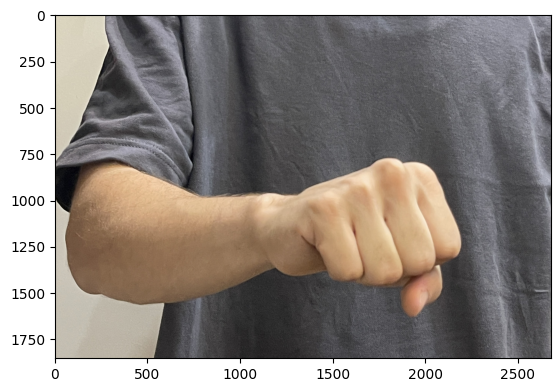

In [6]:
import matplotlib.pyplot as plt

# show one sample (if exists)
sample_imgs = list(train_images.glob("*.*"))
if sample_imgs:
    sample_img = sample_imgs[0]
    sample_label = train_labels / (sample_img.stem + ".txt")
    print("Showing sample:", sample_img.name)
    plt.imshow(plt.imread(sample_img))
else:
    print("No images found in train/images.")

In [7]:
IMG_SIZE = 512

In [8]:
NUMBER_OF_CLASSES = 5

In [9]:
import cv2
import numpy as np
import pandas as pd
from tensorflow.keras.utils import to_categorical

def load_data(img_dir, label_dir):
    images = []
    labels = []
    
    img_files = sorted(list(img_dir.glob("*.*")))
    for img_path in img_files:
        # Wczytanie obrazu
        img = cv2.imread(str(img_path))
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        images.append(img)
        
        # Wczytanie etykiety (zakładamy jedną rękę na obrazek dla uproszczenia)
        label_path = label_dir / (img_path.stem + ".txt")
        if label_path.exists():
            with open(label_path, 'r') as f:
                first_line = f.readline().split()
                if first_line:
                    labels.append(int(first_line[0])) # Bierzemy tylko klasę (pierwsza liczba)
        else:
            labels.append(0) # Domyślna klasa jeśli brak pliku

    return np.array(images) / 255.0, to_categorical(np.array(labels), num_classes=NUMBER_OF_CLASSES)

In [10]:
# Ładowanie
X_train, y_train = load_data(train_images, train_labels)
print(f"Załadowano {X_train.shape[0]} obrazów o kształcie {X_train.shape[1:]}")

X_test, y_test = load_data(test_images, test_labels)
print(f"Załadowano {X_test.shape[0]} obrazów testowych o kształcie {X_test.shape[1:]}")

Załadowano 87 obrazów o kształcie (512, 512, 3)
Załadowano 13 obrazów testowych o kształcie (512, 512, 3)


In [11]:
#!python -m pip install keras

In [12]:
!python -m pip install tensorflow


[notice] A new release of pip available: 22.2.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
from keras import backend as K

print(K.image_data_format())

channels_last


In [14]:
from tensorflow.keras import layers, models

model = models.Sequential([
    # Pierwsza warstwa splotowa - wyciąga krawędzie i proste wzory
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.MaxPooling2D((2, 2)),
    
    # Druga warstwa - bardziej złożone kształty dłoni
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Trzecia warstwa
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Spłaszczenie danych do warstw gęstych (klasyfikatora)
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Zapobiega przeuczeniu
    layers.Dense(NUMBER_OF_CLASSES, activation='softmax') # 5 wyjść (dla każdej klasy znaku)
])

model.summary()

d:\Magisterka\Semestr 3\Uczenie glebokie L\projekt\hand-sign-recognition\.venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 510, 510, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 255, 255, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 253, 253, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 126, 126, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 124, 124, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 62, 62, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 492032)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    62,980,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,074,117 (240.61 MB)

 Trainable params: 63,074,117 (240.61 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [16]:
history = model.fit(X_train, y_train,
                   batch_size=128,
                   epochs=20,
                   validation_data=(X_test, y_test))

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 32s 32s/step - accuracy: 0.1724 - loss: 1.6288 - val_accuracy: 0.0769 - val_loss: 11.6180
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 34s 34s/step - accuracy: 0.2414 - loss: 10.1980 - val_accuracy: 0.2308 - val_loss: 5.1723
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 28s 28s/step - accuracy: 0.2874 - loss: 9.5700 - val_accuracy: 0.3077 - val_loss: 2.6311
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 27s 27s/step - accuracy: 0.2989 - loss: 3.3816 - val_accuracy: 0.2308 - val_loss: 2.4816
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 29s 29s/step - accuracy: 0.2184 - loss: 2.3260 - val_accuracy: 0.4615 - val_loss: 1.5069
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 22s 22s/step - accuracy: 0.2874 - loss: 1.5404 - val_accuracy: 0.1538 - val_loss: 1.6341
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 27s 27s/step - accuracy: 0.2644 - loss: 1.5735 - val_accuracy: 0.3846 - val_loss: 1.5742
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 29s 29s/step - accuracy: 0.5287 - loss: 1.3113 - val_accuracy: 0.3846 - val_loss: 1.511

In [17]:
score = model.evaluate(X_test, y_test)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step - accuracy: 0.5385 - loss: 1.2342
Test loss: 1.2342073917388916
Test accuracy: 0.5384615659713745


In [18]:
def make_accuracy_plot(history):
    """
    Funkcja zwraca wykres dokładności (accuracy) modelu na zbiorze treningowym
    i walidacyjnym.
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    sns.set()
    acc, val_acc = history.history['accuracy'], history.history['val_accuracy']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(10, 8))
    plt.plot(epochs, acc, label='Dokładność trenowania', marker='o')
    plt.plot(epochs, val_acc, label='Dokładność walidacji', marker='o')
    plt.legend()
    plt.title('Dokładność trenowania i walidacji')
    plt.xlabel('Epoki')
    plt.ylabel('Dokładność')
    plt.show()

def make_loss_plot(history):
    """
    Funkcja zwraca wykres straty (loss) modelu na zbiorze treningowym
    i walidacyjnym.
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    sns.set()
    loss, val_loss = history.history['loss'], history.history['val_loss']
    epochs = range(1, len(loss) + 1)

    plt.figure(figsize=(10, 8))
    plt.plot(epochs, loss, label='Strata trenowania', marker='o')
    plt.plot(epochs, val_loss, label='Strata walidacji', marker='o')
    plt.legend()
    plt.title('Strata trenowania i walidacji')
    plt.xlabel('Epoki')
    plt.ylabel('Strata')
    plt.show()

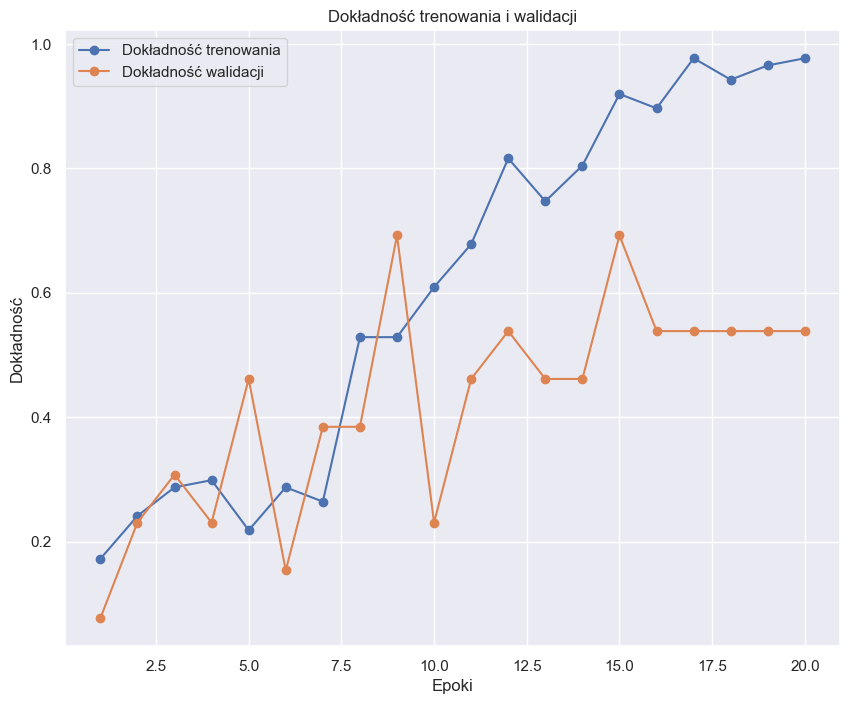

In [19]:
make_accuracy_plot(history)

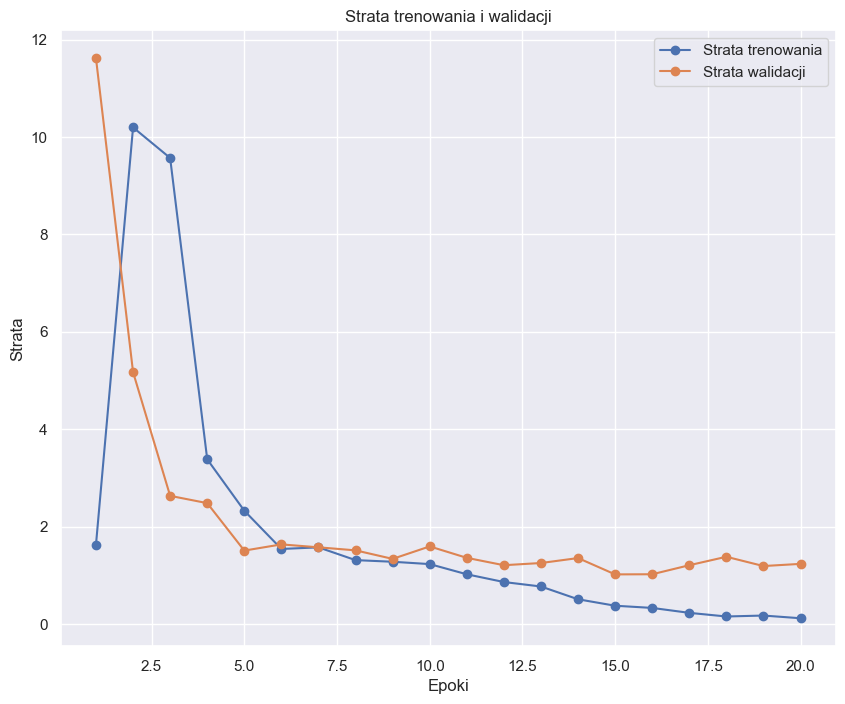

In [20]:
make_loss_plot(history)

In [40]:
predictions = model.predict(X_test[4:5])
class_idx = np.argmax(predictions[0]) # Wybiera indeks z najwyższym prawdopodobieństwem
confidence = predictions[0][class_idx] # Jak pewny jest model
class_names = ['Yes', 'No', 'Hello', 'I love You', 'Thank You']
print(f"Predykcja klasy: {class_names[class_idx]} z pewnością: {confidence:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
Predykcja klasy: Hello z pewnością: 0.8796


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


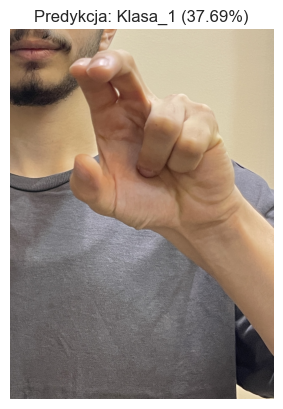

Rozpoznany znak to: Klasa_1


In [49]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def predict_single_image(model, img_path, class_names):
    # 1. Wczytanie i konwersja kolorów (OpenCV wczytuje w BGR, Matplotlib/Keras potrzebują RGB)
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))

    # 3. Normalizacja (podzielenie przez 255, tak jak przy treningu)
    img_normalized = img_resized / 255.0

    input_data = np.expand_dims(img_normalized, axis=0)
    
    # 5. Predykcja
    predictions = model.predict(input_data)
    class_idx = np.argmax(predictions[0]) # Wybiera indeks z najwyższym prawdopodobieństwem
    confidence = predictions[0][class_idx] # Jak pewny jest model
    
    # 6. Wyświetlenie wyniku
    plt.imshow(img_rgb)
    plt.title(f"Predykcja: {class_names[class_idx]} ({confidence*100:.2f}%)")
    plt.axis('off')
    plt.show()
    
    return class_names[class_idx]

# --- PRZYKŁAD UŻYCIA ---
# Zdefiniuj nazwy klas w kolejności takiej, jak w folderze/labelach
my_classes = ['Klasa_0', 'Klasa_1', 'Klasa_2', 'Klasa_3', 'Klasa_4']

# Ścieżka do dowolnego zdjęcia z folderu testowego
test_sample = list(test_images.glob("*.*"))[5]

# Wywołanie funkcji
result = predict_single_image(model, test_sample, my_classes)
print(f"Rozpoznany znak to: {result}")